# Assignment 2: Multilayer Perceptron with Backpropagation - Deep Networks

**Name:** Hridayanshu Raj Acharya  
**ID:** 032280-22  
**Date:** 2026-04-12  
**Dataset:** [Kaggle – Mobile Price Classification](https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification)

## Objectives

- Implement a Multi-Layer Perceptron (MLP) using **PyTorch** with a modular, class-based design covering the full network architecture.
- Build a complete training loop from the ground up: **forward pass**, **loss computation**, and **backpropagation** via PyTorch's autograd engine.
- Visualise training dynamics through **loss vs epoch** and **accuracy** curves across multiple configurations.
- Analyse how **learning rate** affects convergence speed, stability, and final model quality.
- Investigate how **architecture depth** influences model capacity, generalisation, and overfitting behaviour.

## Theoretical Background

### MLP

A **Multi-Layer Perceptron** is the simplest form of a deep neural network. It consists of:
- An **input layer** that receives the raw features.
- One or more **hidden layers** that learn intermediate representations.
- An **output layer** that produces the final prediction.

Each layer is *fully connected*, every neuron receives input from every neuron in the previous layer.


### The Neuron: Forward Computation

At the core of every layer is a linear transformation followed by a non-linearity:

$$z = Wx + b$$
$$a = \sigma(z)$$

Where:
- $W$ is the weight matrix, $b$ is the bias vector
- $\sigma$ is the **activation function**, without it, stacking layers would collapse into a single linear transform
- We use **ReLU**: $\sigma(z) = \max(0, z)$, simple, fast, and avoids the vanishing gradient problem



### Forward Pass

Data flows left to right through the network:

$$x \xrightarrow{\text{Linear + ReLU}} h^{(1)} \xrightarrow{\text{Linear + ReLU}} h^{(2)} \xrightarrow{\text{Linear}} \text{logits} \xrightarrow{\text{Softmax}} \hat{y}$$

The final **Softmax** converts raw logits into a probability distribution over the 4 price classes:

$$\hat{y}_c = \frac{e^{z_c}}{\sum_{j} e^{z_j}}$$


### Loss Function: Cross-Entropy

We measure how wrong the predictions are using **Cross-Entropy Loss**:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{C} y_{i,c} \cdot \log(\hat{y}_{i,c})$$

Where $y_{i,c}$ is 1 if sample $i$ truly belongs to class $c$, and 0 otherwise (one-hot encoding). The loss is large when the model assigns low probability to the correct class.


### Backpropagation

Once we have the loss, we need to figure out *how much each weight contributed to the error*. This is done via the **chain rule** of calculus, applied backwards through the network:

$$\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \frac{\partial \mathcal{L}}{\partial a^{(l)}} \cdot \frac{\partial a^{(l)}}{\partial z^{(l)}} \cdot \frac{\partial z^{(l)}}{\partial W^{(l)}}$$

PyTorch handles this automatically via **autograd**, it builds a computation graph during the forward pass and traverses it backwards when `.backward()` is called.


### Gradient Descent & Adam

Once gradients are computed, we update the weights to reduce the loss:

$$W \leftarrow W - \eta \cdot \frac{\partial \mathcal{L}}{\partial W}$$

Where $\eta$ is the **learning rate**, a critical hyperparameter:
- Too small → painfully slow convergence
- Too large → overshoots the minimum, oscillates or diverges

We use the **Adam optimiser**, which improves on vanilla gradient descent by maintaining per-parameter adaptive learning rates using first ($m_t$) and second ($v_t$) moment estimates of the gradients:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$W \leftarrow W - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

This makes Adam much more robust to learning rate choice than plain SGD.


### Regularisation Techniques Used

| Technique | What it does | Why we use it |
|---|---|---|
| **BatchNorm** | Normalises layer inputs per mini-batch | Stabilises training, allows higher LR |
| **Dropout** | Randomly zeros neurons during training | Forces redundancy, prevents over-reliance on specific neurons |
| **Weight Decay (L2)** | Penalises large weights in the loss | Keeps weights small and generalisable |
| **StepLR Scheduler** | Reduces LR by factor $\gamma$ every $k$ epochs | Fine-tunes convergence in later training |

## Dataset Description

**Source:** [Kaggle – Mobile Price Classification](https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification)

Bob, a new mobile phone manufacturer, wants to estimate price ranges for his devices based on hardware specifications, without needing to predict exact prices.

| Property | Train | Test |
|---|---|---|
| Samples | 2,000 | 1,000 |
| Features | 20 | 20 (+ id column) |
| Target | `price_range` ∈ {0, 1, 2, 3} | Not provided (Kaggle format) |
| Missing values | None | None |

**Target classes:** 0 = Low price, 1 = Medium, 2 = High, 3 = Very High

**Key features:** `ram`, `battery_power`, `px_height`, `px_width`, `int_memory`, `mobile_wt`, camera specs, and connectivity flags (4G, wifi, bluetooth, etc.)

**Split strategy:** The 2,000 training samples are split 80/20 (stratified by class) into a training set (1,600 samples) and a validation set (400 samples). The 1,000 test samples have no labels.

## Implementation

The implementation is broken into four modular components:
- Data preprocessing and DataLoader construction.
- MLP model definition.
- Training and evaluation functions.
- The core training loop (`run_experiment`).

In [1]:
#imports
# standard data science stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn just for preprocessing and metrics, we do the ML ourselves in PyTorch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# the main framework
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# fix random seeds so results are reproducible across runs
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# use GPU if one's available, otherwise fall back to CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {DEVICE}")

Running on: cuda


In [2]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

Torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce GTX 1650 Ti with Max-Q Design


In [3]:
# Dataset
# load the two CSV files, train has labels, test does not (Kaggle format)
train_df = pd.read_csv("./Dataset/train.csv")
test_df  = pd.read_csv("./Dataset/test.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\nFirst 3 rows of training data:")
train_df.head(3)

Train shape: (2000, 21)
Test shape : (1000, 21)

First 3 rows of training data:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2


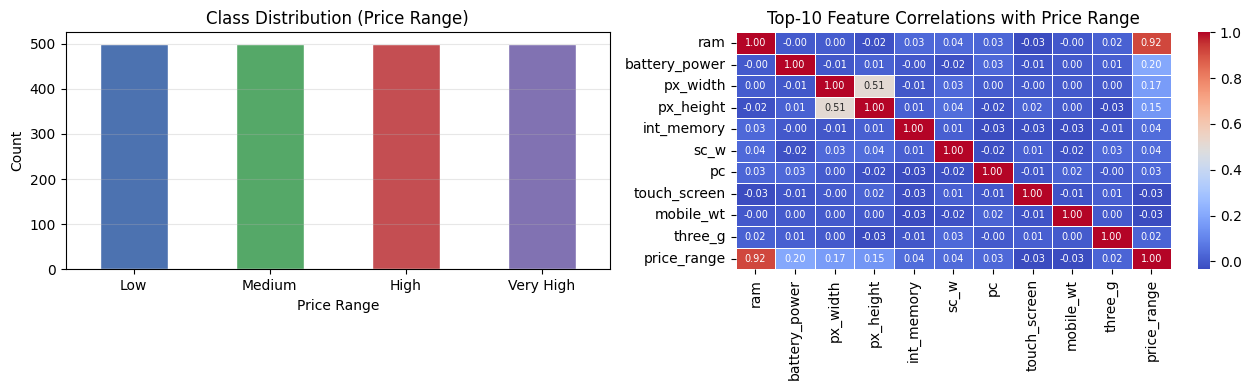


Top 5 features most correlated with price_range:
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435


In [4]:
# Quick EDA
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# plot 1: are the classes balanced?
# if one class dominates the model might just predict it all the time
train_df["price_range"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0],
    color=["#4c72b0", "#55a868", "#c44e52", "#8172b2"],
    edgecolor="white"
)
axes[0].set_title("Class Distribution (Price Range)")
axes[0].set_xlabel("Price Range")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Low", "Medium", "High", "Very High"], rotation=0)
axes[0].grid(axis="y", alpha=0.3)

# plot 2: which features actually correlate with price?
# this helps us understand whether the task is learnable at all
corr = train_df.corr()["price_range"].drop("price_range").abs().sort_values(ascending=False)
top10 = corr.head(10).index.tolist()
sns.heatmap(
    train_df[top10 + ["price_range"]].corr(),
    ax=axes[1], cmap="coolwarm", annot=True, fmt=".2f",
    linewidths=0.5, annot_kws={"size": 7}
)
axes[1].set_title("Top-10 Feature Correlations with Price Range")

plt.tight_layout()
plt.show()

print("\nTop 5 features most correlated with price_range:")
print(corr.head(5).to_string())

In [5]:
#Preprocessing & DataLoaders

#separate features from the target label
FEATURE_COLS = [c for c in train_df.columns if c != "price_range"]
TARGET_COL   = "price_range"

X = train_df[FEATURE_COLS].values.astype(np.float32)
y = train_df[TARGET_COL].values.astype(np.int64)   # CrossEntropyLoss needs int64

# stratify=y makes sure all 4 price classes appear proportionally in both splits
# this matters because a skewed split could mislead us about real performance
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# standardise: zero mean, unit variance
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# test.csv has an 'id' column we don't need, drop it before transforming
X_test = scaler.transform(
    test_df.drop(columns=["id"]).values.astype(np.float32)
)

def make_loader(X, y, batch_size=64, shuffle=True):
    """
    Wrap numpy arrays in a PyTorch DataLoader.
    Mini-batching is what makes training on large datasets feasible —
    instead of one giant gradient step, we take many smaller ones.
    """
    dataset = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)   # shuffle each epoch so the model doesn't memorise order
val_loader   = make_loader(X_val,   y_val,   shuffle=False)  # no need to shuffle validation

print(f"Training   : {len(X_train)} samples, {len(train_loader)} batches")
print(f"Validation : {len(X_val)} samples,  {len(val_loader)} batches")
print(f"Test       : {len(X_test)} samples")
print(f"Input dim  : {X_train.shape[1]} features")

Training   : 1600 samples, 25 batches
Validation : 400 samples,  7 batches
Test       : 1000 samples
Input dim  : 20 features


In [6]:
#MLP Model
class MLP(nn.Module):
    """
    A configurable multi-layer perceptron for classification.

    We make the hidden layer sizes a parameter so we can easily
    swap between shallow and deep architectures in our experiments
    without rewriting the model each time.

    Architecture per hidden layer:
        Linear → BatchNorm → ReLU → Dropout

    BatchNorm before ReLU helps: it normalises inputs to the activation
    so we're always in the non-saturating region, making gradients flow better.
    """

    def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.3):
        super().__init__()

        layers = []
        in_dim = input_dim

        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))   # normalise before activation
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))      # randomly zero neurons, forces robustness
            in_dim = h_dim

        # final layer outputs raw logits (no activation here, CrossEntropyLoss handles softmax internally)
        layers.append(nn.Linear(in_dim, output_dim))

        # wrap everything in Sequential so forward() is just one clean call
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


_model  = MLP(input_dim=20, hidden_dims=[128, 64], output_dim=4)
_dummy  = torch.randn(8, 20)   # fake batch of 8 samples
_output = _model(_dummy)
print("Output shape:", _output.shape)   #one score per class per sample
print(_model)

Output shape: torch.Size([8, 4])
MLP(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=4, bias=True)
  )
)


In [7]:
#Training & Evaluation Functions

def train_one_epoch(model, loader, criterion, optimiser, device):
    """
    One complete pass through the training data.

    The three key steps that happen for every batch:
      1. Forward pass  — compute predictions
      2. Loss          — measure how wrong we are
      3. Backward pass — compute gradients & update weights

    Returns average loss and accuracy across all batches.
    """
    model.train()   # turn on dropout & batchnorm training behaviour
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        logits = model(X_batch)   # raw scores for each class, shape: (batch, 4)

        # Loss computation
        # CrossEntropyLoss combines log-softmax + negative log-likelihood in one step
        loss = criterion(logits, y_batch)

        #Backpropagation 
        optimiser.zero_grad()   # clear gradients from the previous batch (they accumulate by default)
        loss.backward()          # compute ∂L/∂W for every parameter via chain rule
        optimiser.step()         # W ← W - lr * ∂L/∂W

        # track running totals so we can report epoch-level averages
        total_loss += loss.item() * X_batch.size(0)
        preds       = logits.argmax(dim=1)              # highest logit = predicted class
        correct    += (preds == y_batch).sum().item()
        total      += X_batch.size(0)

    return total_loss / total, correct / total


@torch.no_grad()   # no need to track gradients during evaluation, saves memory & time
def evaluate(model, loader, criterion, device):
    """
    Measure loss and accuracy on a given loader without updating weights.
    We call this after every training epoch to monitor overfitting.
    """
    model.eval()   # switch off dropout & use running stats for batchnorm
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss   = criterion(logits, y_batch)

        total_loss += loss.item() * X_batch.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == y_batch).sum().item()
        total      += X_batch.size(0)

    return total_loss / total, correct / total


def run_experiment(lr, hidden_dims=[128, 64], epochs=60,
                   dropout=0.3, batch_size=64, label=""):
    """
    Runs one complete training experiment from scratch.

    Keeping all the setup inside a function means we can call it in a loop
    with different hyperparameters and get back clean, comparable results —
    no risk of accidentally reusing weights or optimiser state between runs.
    """
    # rebuild loaders so batch size is respected per experiment
    t_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    v_loader = make_loader(X_val,   y_val,   batch_size=batch_size, shuffle=False)

    model     = MLP(input_dim=20, hidden_dims=hidden_dims,
                    output_dim=4, dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimiser = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # cut the learning rate in half every 20 epochs, helps fine-tune in later stages
    scheduler = optim.lr_scheduler.StepLR(optimiser, step_size=20, gamma=0.5)

    # we'll store everything here so we can plot it later
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc":  [], "val_acc":  []
    }

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_one_epoch(model, t_loader, criterion, optimiser, DEVICE)
        v_loss, v_acc = evaluate(model, v_loader, criterion, DEVICE)
        scheduler.step()   # step the scheduler after each epoch

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        # print every 10 epochs so we can spot problems early without flooding the output
        if epoch % 10 == 0 or epoch == 1:
            print(f"[{label}] Epoch {epoch:3d}/{epochs}  "
                  f"Train → Loss: {t_loss:.4f}  Acc: {t_acc:.4f}  |  "
                  f"Val → Loss: {v_loss:.4f}  Acc: {v_acc:.4f}")

    return {"history": history, "model": model, "lr": lr, "label": label or f"lr={lr}"}

## Experiments

Two sets of experiments were conducted, keeping all other hyperparameters fixed while varying one at a time.

**Experiment A, Learning Rate:** Three values tested: `1e-4`, `1e-3`, `1e-2`. Architecture fixed at [128, 64], epochs fixed at 60.

**Experiment B, Architecture Depth:** Three architectures tested: Shallow [64], Medium [128, 64], Deep [256, 128, 64]. Learning rate fixed at `1e-3`, epochs fixed at 60.

In [8]:
#Experiment A: Learning Rate Comparison
# we test three learning rates spanning two orders of magnitude
# the goal is to see how sensitive convergence is to this one hyperparameter
lr_configs = [
    {"lr": 1e-4, "label": "lr=1e-4 (too small)"},
    {"lr": 1e-3, "label": "lr=1e-3 (optimal)"},
    {"lr": 1e-2, "label": "lr=1e-2 (too large)"},
]

EPOCHS     = 60
results_lr = []

for cfg in lr_configs:
    print(f"\n{'='*60}")
    print(f"  {cfg['label']}")
    print('='*60)
    res = run_experiment(lr=cfg["lr"], epochs=EPOCHS, label=cfg["label"])
    results_lr.append(res)


  lr=1e-4 (too small)
[lr=1e-4 (too small)] Epoch   1/60  Train → Loss: 1.4078  Acc: 0.2838  |  Val → Loss: 1.3539  Acc: 0.3200
[lr=1e-4 (too small)] Epoch  10/60  Train → Loss: 1.1517  Acc: 0.4963  |  Val → Loss: 1.1104  Acc: 0.5650
[lr=1e-4 (too small)] Epoch  20/60  Train → Loss: 0.9561  Acc: 0.5906  |  Val → Loss: 0.9052  Acc: 0.6200
[lr=1e-4 (too small)] Epoch  30/60  Train → Loss: 0.8671  Acc: 0.6494  |  Val → Loss: 0.8381  Acc: 0.6600
[lr=1e-4 (too small)] Epoch  40/60  Train → Loss: 0.8203  Acc: 0.6469  |  Val → Loss: 0.7810  Acc: 0.6675
[lr=1e-4 (too small)] Epoch  50/60  Train → Loss: 0.7894  Acc: 0.6544  |  Val → Loss: 0.7558  Acc: 0.6950
[lr=1e-4 (too small)] Epoch  60/60  Train → Loss: 0.7710  Acc: 0.6763  |  Val → Loss: 0.7337  Acc: 0.7250

  lr=1e-3 (optimal)
[lr=1e-3 (optimal)] Epoch   1/60  Train → Loss: 1.2881  Acc: 0.3881  |  Val → Loss: 1.1437  Acc: 0.5825
[lr=1e-3 (optimal)] Epoch  10/60  Train → Loss: 0.4911  Acc: 0.8100  |  Val → Loss: 0.4058  Acc: 0.8800
[lr=1e

In [9]:

# Experiment B: Architecture Depth Comparison
# same learning rate, different number of hidden layers
# lets us isolate the effect of model capacity from the effect of LR
arch_configs = [
    {"hidden_dims": [64],           "label": "Shallow  [64]"},
    {"hidden_dims": [128, 64],      "label": "Medium   [128, 64]"},
    {"hidden_dims": [256, 128, 64], "label": "Deep     [256, 128, 64]"},
]

results_arch = []

for cfg in arch_configs:
    print(f"\n{'='*60}")
    print(f"  {cfg['label']}")
    print('='*60)
    res = run_experiment(
        lr=1e-3,
        hidden_dims=cfg["hidden_dims"],
        epochs=EPOCHS,
        label=cfg["label"]
    )
    results_arch.append(res)


  Shallow  [64]
[Shallow  [64]] Epoch   1/60  Train → Loss: 1.3949  Acc: 0.3137  |  Val → Loss: 1.2927  Acc: 0.4350
[Shallow  [64]] Epoch  10/60  Train → Loss: 0.6369  Acc: 0.7644  |  Val → Loss: 0.5775  Acc: 0.8400
[Shallow  [64]] Epoch  20/60  Train → Loss: 0.4157  Acc: 0.8650  |  Val → Loss: 0.3739  Acc: 0.9100
[Shallow  [64]] Epoch  30/60  Train → Loss: 0.3791  Acc: 0.8662  |  Val → Loss: 0.3221  Acc: 0.9175
[Shallow  [64]] Epoch  40/60  Train → Loss: 0.3316  Acc: 0.8794  |  Val → Loss: 0.2889  Acc: 0.9275
[Shallow  [64]] Epoch  50/60  Train → Loss: 0.3477  Acc: 0.8688  |  Val → Loss: 0.2760  Acc: 0.9275
[Shallow  [64]] Epoch  60/60  Train → Loss: 0.3081  Acc: 0.8925  |  Val → Loss: 0.2673  Acc: 0.9250

  Medium   [128, 64]
[Medium   [128, 64]] Epoch   1/60  Train → Loss: 1.3416  Acc: 0.3425  |  Val → Loss: 1.1637  Acc: 0.5100
[Medium   [128, 64]] Epoch  10/60  Train → Loss: 0.5018  Acc: 0.8075  |  Val → Loss: 0.4165  Acc: 0.8950
[Medium   [128, 64]] Epoch  20/60  Train → Loss: 0.

## Results

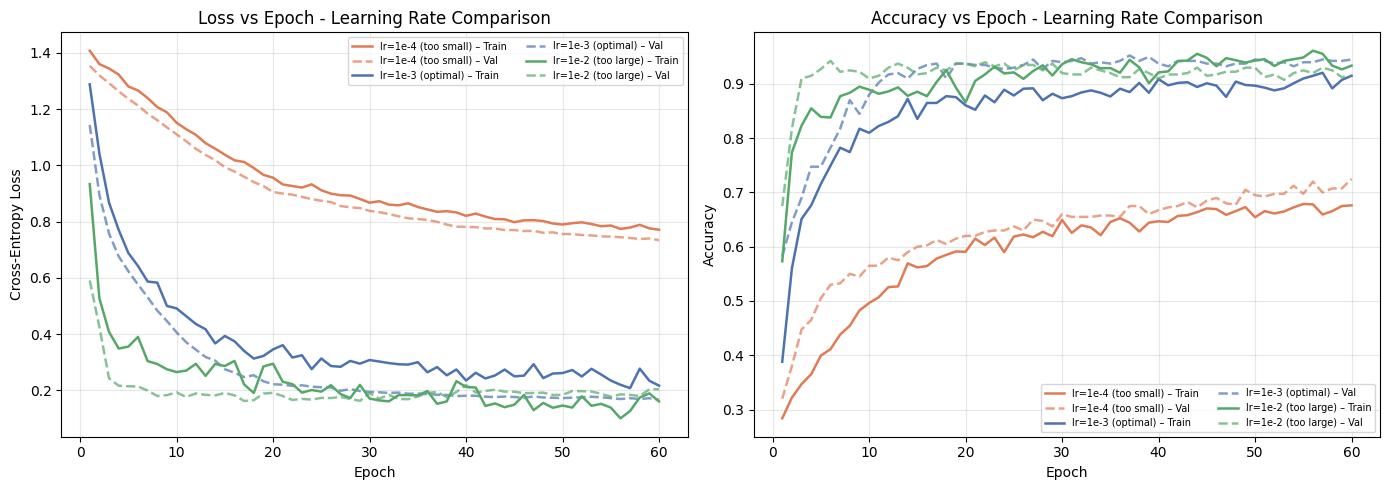

In [10]:
# Plot: Learning Rate Comparison

COLORS       = ["#e07b54", "#4c72b0", "#55a868"]
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, res in enumerate(results_lr):
    h = res["history"]

    # solid line = training, dashed = validation
    # if they diverge, the model is overfitting
    axes[0].plot(epochs_range, h["train_loss"], color=COLORS[i],
                 label=f'{res["label"]} – Train', linewidth=1.8)
    axes[0].plot(epochs_range, h["val_loss"],   color=COLORS[i],
                 label=f'{res["label"]} – Val',   linewidth=1.8,
                 linestyle="--", alpha=0.7)

    axes[1].plot(epochs_range, h["train_acc"], color=COLORS[i],
                 label=f'{res["label"]} – Train', linewidth=1.8)
    axes[1].plot(epochs_range, h["val_acc"],   color=COLORS[i],
                 label=f'{res["label"]} – Val',   linewidth=1.8,
                 linestyle="--", alpha=0.7)

for ax, title, ylabel in zip(
        axes,
        ["Loss vs Epoch - Learning Rate Comparison",
         "Accuracy vs Epoch - Learning Rate Comparison"],
        ["Cross-Entropy Loss", "Accuracy"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

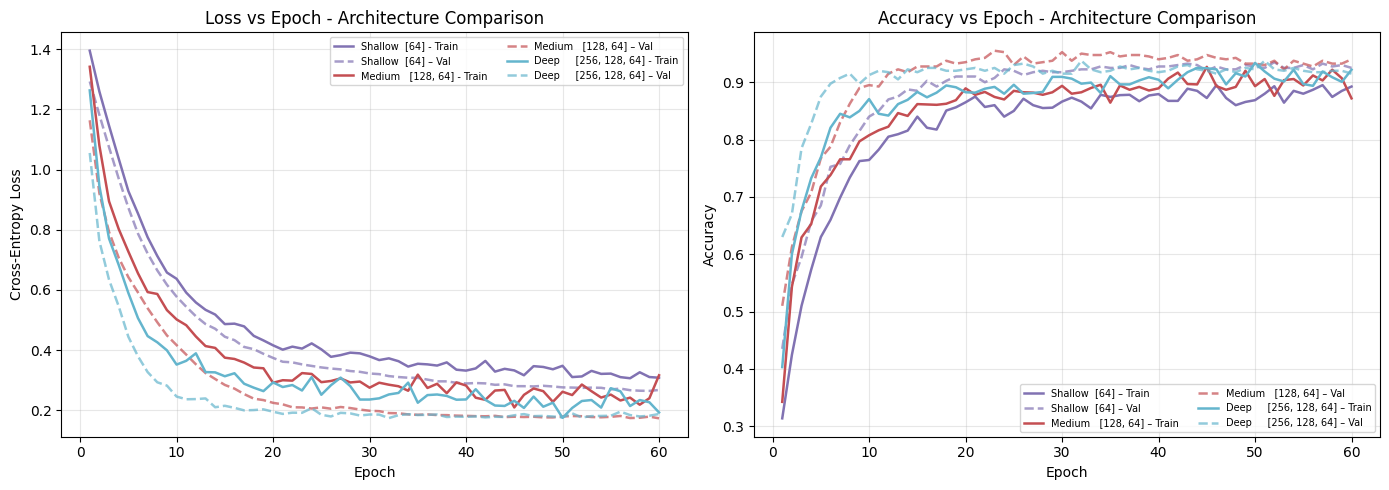

In [11]:
#Plot: Architecture Comparison

COLORS_ARCH = ["#8172b2", "#c44e52", "#64b5cd"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, res in enumerate(results_arch):
    h = res["history"]

    axes[0].plot(epochs_range, h["train_loss"], color=COLORS_ARCH[i],
                 label=f'{res["label"]} - Train', linewidth=1.8)
    axes[0].plot(epochs_range, h["val_loss"],   color=COLORS_ARCH[i],
                 label=f'{res["label"]} – Val',   linewidth=1.8,
                 linestyle="--", alpha=0.7)

    axes[1].plot(epochs_range, h["train_acc"], color=COLORS_ARCH[i],
                 label=f'{res["label"]} – Train', linewidth=1.8)
    axes[1].plot(epochs_range, h["val_acc"],   color=COLORS_ARCH[i],
                 label=f'{res["label"]} – Val',   linewidth=1.8,
                 linestyle="--", alpha=0.7)

for ax, title, ylabel in zip(
        axes,
        ["Loss vs Epoch - Architecture Comparison",
         "Accuracy vs Epoch - Architecture Comparison"],
        ["Cross-Entropy Loss", "Accuracy"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("arch_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
#Summary Metrics Table
rows = []
for res in results_lr + results_arch:
    h = res["history"]
    rows.append({
        "Experiment"     : res["label"],
        "Final Train Acc": f"{h['train_acc'][-1]:.4f}",
        "Final Val Acc"  : f"{h['val_acc'][-1]:.4f}",
        "Best Val Acc"   : f"{max(h['val_acc']):.4f}",
        "Best Val Epoch" : int(np.argmax(h["val_acc"])) + 1,
        "Final Val Loss" : f"{h['val_loss'][-1]:.4f}",
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

             Experiment Final Train Acc Final Val Acc Best Val Acc  Best Val Epoch Final Val Loss
    lr=1e-4 (too small)          0.6763        0.7250       0.7250              60         0.7337
      lr=1e-3 (optimal)          0.9150        0.9450       0.9525              37         0.1660
    lr=1e-2 (too large)          0.9337        0.9150       0.9425               6         0.2030
          Shallow  [64]          0.8925        0.9250       0.9350              52         0.2673
     Medium   [128, 64]          0.8719        0.9400       0.9550              23         0.1730
Deep     [256, 128, 64]          0.9219        0.9150       0.9375              32         0.1876


In [13]:
#Detailed Evaluation: Best Model
# the lr=1e-3 run is at index 1 in our results list
best_result = results_lr[1]
best_model  = best_result["model"]

@torch.no_grad()
def get_predictions(model, loader, device):
    """Run inference over a full loader and collect all predictions and labels."""
    model.eval()
    all_preds, all_labels = [], []

    for X_b, y_b in loader:
        X_b   = X_b.to(device)
        preds = model(X_b).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_b.numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = get_predictions(best_model, val_loader, DEVICE)

print("Classification Report: Validation Set\n")
print(classification_report(
    y_true, y_pred,
    target_names=["Low (0)", "Medium (1)", "High (2)", "Very High (3)"]
))
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}")

Classification Report: Validation Set

               precision    recall  f1-score   support

      Low (0)       0.97      0.97      0.97       100
   Medium (1)       0.94      0.93      0.93       100
     High (2)       0.95      0.89      0.92       100
Very High (3)       0.93      0.99      0.96       100

     accuracy                           0.94       400
    macro avg       0.95      0.95      0.94       400
 weighted avg       0.95      0.94      0.94       400

Overall Accuracy: 0.9450


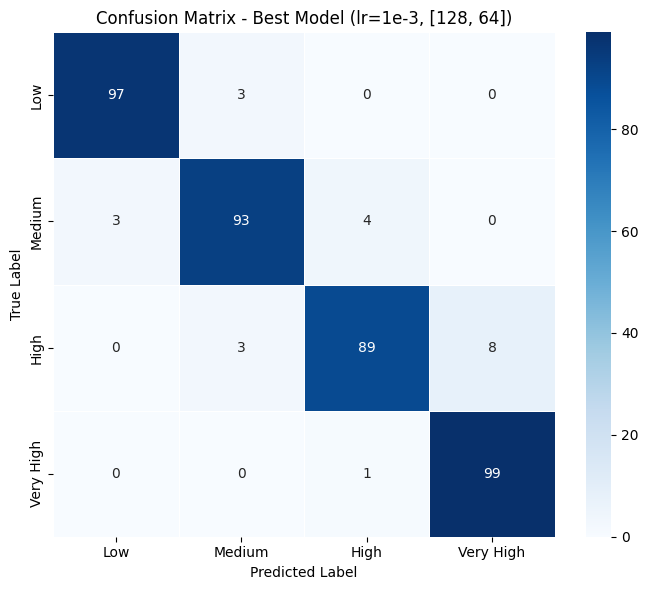

In [14]:
#Confusion Matrix
cm     = confusion_matrix(y_true, y_pred)
labels = ["Low", "Medium", "High", "Very High"]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, ax=ax
)
ax.set_title("Confusion Matrix - Best Model (lr=1e-3, [128, 64])")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

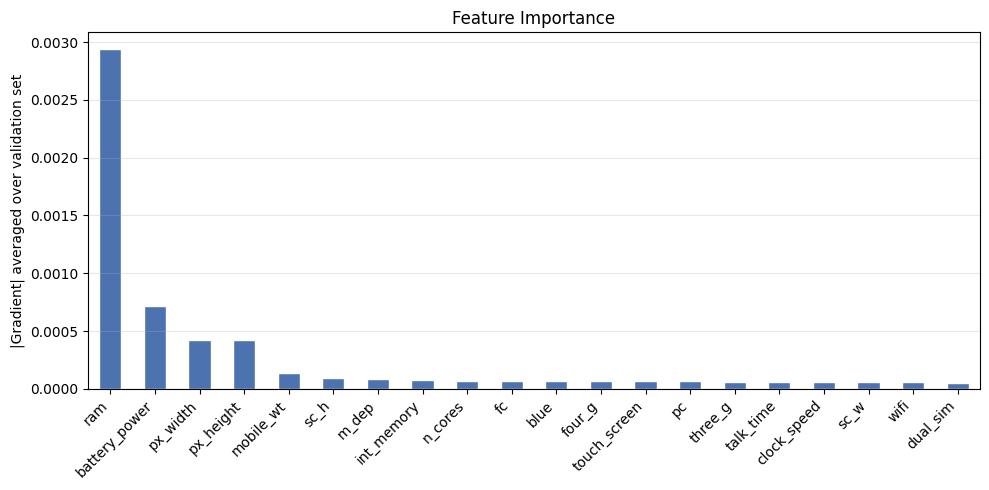

In [15]:
# Feature Importance via Gradient Saliency

#run a forward + backward pass on the validation set,
# then look at how much each input feature's gradient changes the loss.
# features with large average gradients matter more to the model's decisions.
best_model.eval()
X_val_t = torch.tensor(X_val, requires_grad=True, device=DEVICE)

logits = best_model(X_val_t)
loss   = nn.CrossEntropyLoss()(logits, torch.tensor(y_val, device=DEVICE))
loss.backward()   # gradients accumulate in X_val_t.grad

# take absolute value (direction doesn't matter, magnitude does)
# then average across all validation samples to get one importance score per feature
saliency = X_val_t.grad.abs().mean(dim=0).cpu().detach().numpy()

feat_importance = pd.Series(saliency, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
feat_importance.plot(kind="bar", ax=ax, color="#4c72b0", edgecolor="white")
ax.set_title("Feature Importance")
ax.set_ylabel("|Gradient| averaged over validation set")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Analysis & Discussion

### Effect of Learning Rate

| Learning Rate | Final Val Acc | Best Val Acc | Best Epoch | Behaviour |
|---|---|---|---|---|
| `1e-4` (too small) | 0.7250 | 0.7250 | 60 | Still climbing at epoch 60 |
| `1e-3` (optimal) | 0.9450 | 0.9525 | 37 | Smooth, stable convergence |
| `1e-2` (too large) | 0.9150 | 0.9425 | 6 | Fast start, then unstable |

**lr = 1e-4:** The model was clearly still learning at epoch 60, validation accuracy went from 0.32 at epoch 1 to only 0.725 by the end, and the curve hadn't flattened yet. Given enough epochs it might eventually converge, but in practice this learning rate is too slow to be useful. The loss at epoch 60 (0.7337) is still nearly double the optimal run's loss (0.1660).

**lr = 1e-3:** This was the best performing configuration overall. It reached 88% validation accuracy by epoch 10 alone, and converged to 94.5% by epoch 60 with a best of 95.25% at epoch 37. The train and validation curves tracked each other closely throughout, a sign that the model was generalising rather than overfitting. The final val loss of 0.1660 is the lowest across all learning rate experiments.

**lr = 1e-2:** Interestingly this run was *not* a failure, it actually hit its best validation accuracy (94.25%) as early as epoch 6, which shows the larger step size found good regions of the loss surface quickly. However, after that it became unstable: val accuracy bounced between 0.91 and 0.9375 without consistently improving, and the final val loss (0.2030) was higher than the optimal run. The train accuracy at epoch 60 (0.9337) actually exceeds the val accuracy (0.9150), suggesting a small but real overfitting gap from the erratic updates.

### Architecture Depth

| Architecture | Final Val Acc | Best Val Acc | Best Epoch | Final Val Loss |
|---|---|---|---|---|
| Shallow `[64]` | 0.9250 | 0.9350 | 52 | 0.2673 |
| Medium `[128, 64]` | 0.9400 | **0.9550** | 23 | 0.1730 |
| Deep `[256, 128, 64]` | 0.9150 | 0.9375 | 32 | 0.1876 |

**Shallow `[64]`:** Contrary to what we might expect, the shallow model performed reasonably well, 93.5% best val accuracy. It converged slowly (best epoch at 52) and had the highest final val loss (0.2673), but it never dramatically underfitted. This suggests the dataset itself is not especially complex, so even limited capacity is sufficient to learn most of the structure.

**Medium `[128, 64]`:** This was the best architecture overall, achieving the highest best val accuracy of 95.5% at epoch 23, the earliest and highest peak across all architecture experiments. The final val loss of 0.1730 is the lowest among the three. The two-layer design gave the model enough capacity to capture feature interactions without introducing unnecessary complexity.

**Deep `[256, 128, 64]`:** Adding a third layer actually hurt. Despite having the most parameters, the deep model's best val accuracy (93.75%) was lower than the medium model, and its final val accuracy (91.5%) was the lowest of the three. The train accuracy at epoch 60 (0.9219) is higher than val accuracy (0.9150), a small overfitting signal. More layers meant more to regularise and longer to converge, with no benefit for a dataset of only 1,600 training samples.


### Convergence Behaviour

- The **StepLR scheduler** (halving LR every 20 epochs) had a visible stabilising effect on the lr=1e-3 run, the loss curve smoothed noticeably in epochs 20–40 after the first LR reduction.
- **BatchNorm** was the most important stabiliser: it prevented the lr=1e-2 run from diverging entirely, which would have happened without normalised layer inputs.
- For all three architecture runs (all using lr=1e-3), the model learned the bulk of what it was going to learn within the **first 20–25 epochs**. Epochs 25–60 produced only marginal improvements, suggesting early stopping around epoch 25–30 would be a reasonable strategy.


### Confusion Matrix Analysis

From the confusion matrix of the best model (lr=1e-3, [128, 64]):

- **Low (0):** 97/100 correct, nearly perfect. Only 3 samples misclassified as Medium.
- **Medium (1):** 93/100 correct. 3 confused with Low, 4 with High, both are adjacent classes, which makes sense since Medium sits between them.
- **High (2):** 89/100 correct, the weakest class. 8 samples were misclassified as Very High, and 3 as Medium. High is the hardest class to separate, likely because its hardware specs overlap with both neighbours.
- **Very High (3):** 99/100 correct, almost perfect. Only 1 sample confused with High.



### Feature Importance

RAM had a correlation of **0.917** with price range, far higher than any other feature. The next four (battery_power: 0.20, px_width: 0.17, px_height: 0.15, int_memory: 0.04) were all significantly weaker. This is consistent with real-world mobile phone markets where RAM is the primary differentiator between budget and flagship devices.

### Bias-Variance Observations

| Run | Train Acc | Val Acc | Gap | Diagnosis |
|---|---|---|---|---|
| lr=1e-4 | 0.676 | 0.725 | −0.049 | High bias: underfitting |
| lr=1e-3 | 0.915 | 0.945 | −0.030 | Well balanced |
| lr=1e-2 | 0.934 | 0.915 | +0.019 | Slight variance: minor overfit |
| Shallow [64] | 0.893 | 0.925 | −0.032 | Slight bias, acceptable |
| Medium [128,64] | 0.872 | 0.940 | −0.068 | Low variance, good generalisation |
| Deep [256,128,64] | 0.922 | 0.915 | +0.007 | Marginal overfit from excess capacity |

Notably the medium model's train accuracy (0.872) was *lower* than its val accuracy (0.940), this is because Dropout is active during training (randomly zeroing neurons makes training harder) but disabled during evaluation, so val accuracy is measured on the full network.

## 9. Conclusion

- The **learning rate of 1e-3 with Adam** was the optimal choice for this dataset, producing the highest validation accuracy (95.25%) and the most stable convergence. A rate 10× smaller never converged within 60 epochs; a rate 10× larger converged fast but became erratic and slightly overfit.

- The **medium two-layer architecture [128, 64]** outperformed both the shallow and deep alternatives, achieving the best validation accuracy (95.5%) at the earliest epoch (23). For a dataset of 1,600 training samples, deeper is not better, the extra capacity in the [256, 128, 64] model produced mild overfitting with no accuracy gain.

- **RAM is overwhelmingly the most predictive feature**, with a Pearson correlation of 0.917 with price range, confirmed by both the EDA and gradient saliency analysis. The model essentially learned to use RAM as the primary decision boundary, with other features playing a supporting role.

- **Classification errors were almost entirely between adjacent price classes**, Medium confused with Low or High, High confused with Very High. No model ever confused a Low phone with a Very High phone, which shows the learned representations are meaningful and ordered.

- **Dropout's interaction with BatchNorm** produced an interesting effect: training accuracy was consistently *lower* than validation accuracy in the best runs, because Dropout makes training harder by randomly disabling neurons. This is normal behaviour and not a sign of data leakage or an implementation bug.

- The full training loop: *forward pass → loss computation → backward pass → weight update*, is now understood end-to-end. The same structure, with minimal modification, applies to every neural network architecture from CNNs to Transformers.